In [2]:
# -------------------------------------------------------------
# Name: Ajay Krishnan T
# Roll Number: 24BAD006
# Experiment: Probabilistic Classification using Naïve Bayes
# Scenario 1: Multinomial Naïve Bayes - SMS Spam Detection
# -------------------------------------------------------------

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

import nltk
import re
from nltk.corpus import stopwords

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [5]:

df = pd.read_csv('spam.csv', encoding='latin-1')

df = df[['v1','v2']]
df.columns = ['label','message']

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^\w\s]', '', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df['clean_message'] = df['message'].apply(clean_text)

df.head()

,label,message,clean_message
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...
3,ham,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


In [7]:
vectorizer = CountVectorizer()

X = vectorizer.fit_transform(df['clean_message'])

y = df['label']

In [8]:
y = y.map({'ham':0,'spam':1})

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)
model = MultinomialNB()

model.fit(X_train,y_train)
y_pred = model.predict(X_test)

In [10]:
print("Accuracy:", accuracy_score(y_test,y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test,y_pred))

Accuracy: 0.9739910313901345

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.98      0.98       965
           1       0.90      0.91      0.90       150

    accuracy                           0.97      1115
   macro avg       0.94      0.95      0.94      1115
weighted avg       0.97      0.97      0.97      1115



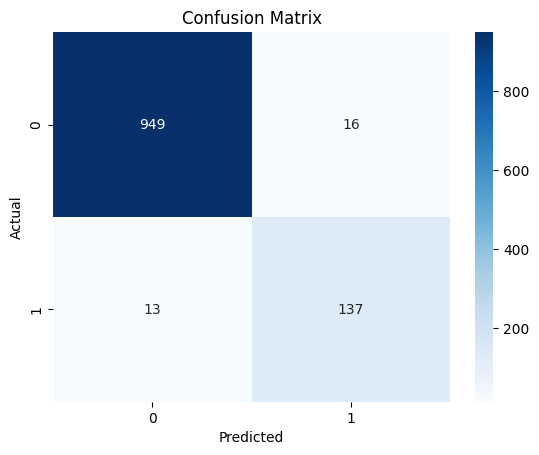

In [11]:
cm = confusion_matrix(y_test,y_pred)

sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [12]:
misclassified = []

for i in range(len(y_test)):

    if y_test.iloc[i] != y_pred[i]:
        misclassified.append(i)

print("Number of misclassified examples:",len(misclassified))

Number of misclassified examples: 29


In [13]:
model_smooth = MultinomialNB(alpha=1.0)

model_smooth.fit(X_train,y_train)

y_pred_smooth = model_smooth.predict(X_test)

print("Accuracy with Laplace Smoothing:",
      accuracy_score(y_test,y_pred_smooth))

Accuracy with Laplace Smoothing: 0.9739910313901345


In [14]:
feature_names = vectorizer.get_feature_names_out()

spam_words = model.feature_log_prob_[1]

top_spam = np.argsort(spam_words)[-20:]

for i in top_spam:
    print(feature_names[i])

16
tone
please
win
send
urgent
nokia
cash
new
get
prize
reply
text
stop
claim
mobile
ur
txt
free
call


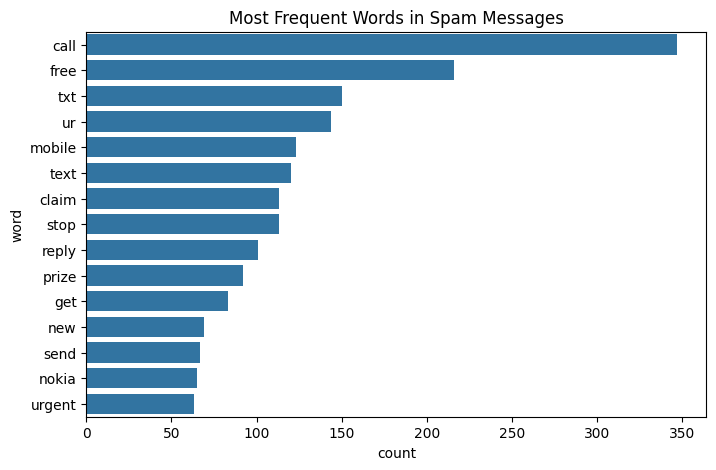

In [15]:
spam_messages = df[df['label']=='spam']['clean_message']

vectorizer2 = CountVectorizer()

spam_matrix = vectorizer2.fit_transform(spam_messages)

word_counts = np.array(spam_matrix.sum(axis=0)).flatten()

words = vectorizer2.get_feature_names_out()

freq = pd.DataFrame({'word':words,'count':word_counts})

top_words = freq.sort_values(by='count',ascending=False).head(15)

plt.figure(figsize=(8,5))
sns.barplot(x='count',y='word',data=top_words)

plt.title("Most Frequent Words in Spam Messages")
plt.show()

In [16]:
# -------------------------------------------------------------
# Name: Ajay Krishnan T
# Roll Number: 24BAD006
# Scenario 2: Gaussian Naïve Bayes - Iris Flower Classification
# -------------------------------------------------------------

In [17]:
from sklearn.datasets import load_iris
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler

In [18]:
iris = load_iris()

X = iris.data
y = iris.target

print(iris.feature_names)
print(iris.target_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']


In [19]:
df_iris = pd.DataFrame(X,columns=iris.feature_names)

df_iris['species'] = y

df_iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [20]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [21]:
X_train,X_test,y_train,y_test = train_test_split(
    X_scaled,y,test_size=0.2,random_state=42
)
gnb = GaussianNB()

gnb.fit(X_train,y_train)
y_pred = gnb.predict(X_test)

In [22]:
print("Accuracy:",accuracy_score(y_test,y_pred))

print("\nClassification Report\n")

print(classification_report(y_test,y_pred))

Accuracy: 1.0

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



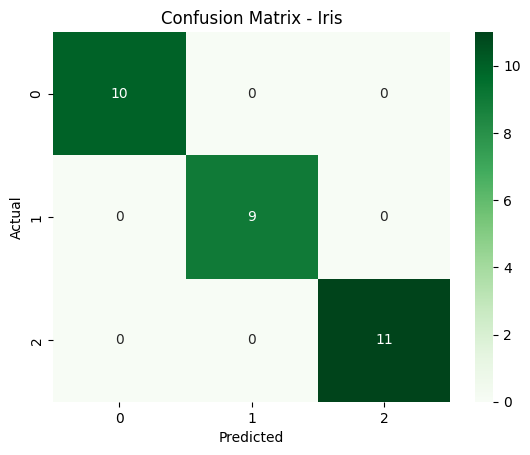

In [23]:
cm = confusion_matrix(y_test,y_pred)

sns.heatmap(cm,annot=True,fmt='d',cmap='Greens')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix - Iris")

plt.show()

In [24]:
probabilities = gnb.predict_proba(X_test)

print("Class Probabilities for first 5 samples:\n")

print(probabilities[:5])

Class Probabilities for first 5 samples:

[[5.97322611e-090 9.95635768e-001 4.36423247e-003]
 [1.00000000e+000 4.96157683e-014 6.54921950e-021]
 [7.31861098e-290 4.92947289e-012 1.00000000e+000]
 [2.81838335e-094 9.77593560e-001 2.24064404e-002]
 [1.13876385e-105 8.70022604e-001 1.29977396e-001]]


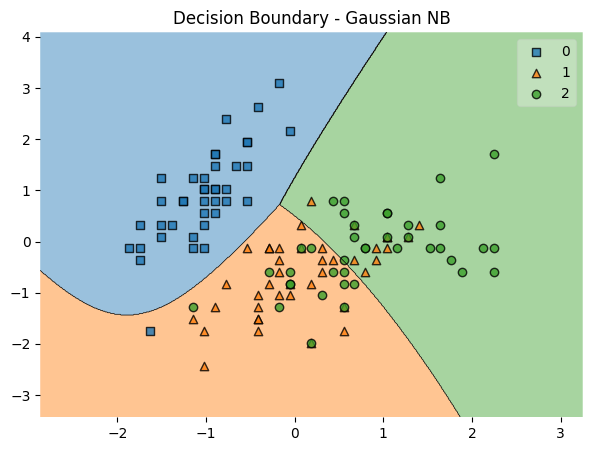

In [25]:
from mlxtend.plotting import plot_decision_regions

X2 = X_scaled[:, :2]

X_train,X_test,y_train,y_test = train_test_split(
    X2,y,test_size=0.2,random_state=42
)

gnb.fit(X_train,y_train)

plt.figure(figsize=(7,5))

plot_decision_regions(X_train,y_train,clf=gnb)

plt.title("Decision Boundary - Gaussian NB")

plt.show()

In [26]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train,y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test,y_pred_lr))

Logistic Regression Accuracy: 0.9
